In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style for plots
sns.set_style("whitegrid")

In [3]:
# Historical Sales Data
sales = pd.DataFrame({
    'Product': ['Dates','Rice','Cooking Oil','Beverages','Clothing','Gram Flour','Chickpeas']*5,
    'Year': [2019,2019,2019,2019,2019,2019,2019,
             2020,2020,2020,2020,2020,2020,2020,
             2021,2021,2021,2021,2021,2021,2021,
             2022,2022,2022,2022,2022,2022,2022,
             2023,2023,2023,2023,2023,2023,2023],
    'Units_Sold': [120,200,150,180,90,70,60, 130,210,160,190,100,80,65,
                   140,220,155,200,110,85,70, 150,230,165,210,120,90,75,
                   160,240,170,220,130,95,80],
    'Price': [500,1500,1200,300,2000,400,350]*5,
    'Promotion_Flag': ['Yes','No','Yes','No','Yes','No','No']*5
})
sales.head()

,Product,Year,Units_Sold,Price,Promotion_Flag
0,Dates,2019,120,500,Yes
1,Rice,2019,200,1500,No
2,Cooking Oil,2019,150,1200,Yes
3,Beverages,2019,180,300,No
4,Clothing,2019,90,2000,Yes


In [4]:
promotions = pd.DataFrame({
    'Product': ['Dates','Rice','Cooking Oil','Beverages','Clothing','Gram Flour','Chickpeas'],
    'Year': [2023]*7,
    'Promotion_Type': ['Discount','Bundle','Discount','Discount','Bundle','Discount','Discount'],
    'Discount_Percentage': [10,0,15,5,0,12,8]
})
promotions

,Product,Year,Promotion_Type,Discount_Percentage
0,Dates,2023,Discount,10
1,Rice,2023,Bundle,0
2,Cooking Oil,2023,Discount,15
3,Beverages,2023,Discount,5
4,Clothing,2023,Bundle,0
5,Gram Flour,2023,Discount,12
6,Chickpeas,2023,Discount,8


In [5]:
inventory = pd.DataFrame({
    'Product': ['Dates','Rice','Cooking Oil','Beverages','Clothing','Gram Flour','Chickpeas'],
    'Current_Stock': [50,200,80,150,60,90,70],
    'Supplier_Lead_Time_Days': [5,7,6,4,8,5,6]
})
inventory

,Product,Current_Stock,Supplier_Lead_Time_Days
0,Dates,50,5
1,Rice,200,7
2,Cooking Oil,80,6
3,Beverages,150,4
4,Clothing,60,8
5,Gram Flour,90,5
6,Chickpeas,70,6


In [6]:
external = pd.DataFrame({
    'Year':[2019,2020,2021,2022,2023],
    'Weather':['Hot','Moderate','Hot','Cold','Hot'],
    'Inflation':[5,6,5.5,6.2,6],
    'Competitor_Promotion_Flag':['No','Yes','Yes','No','Yes']
})
external

,Year,Weather,Inflation,Competitor_Promotion_Flag
0,2019,Hot,5.0,No
1,2020,Moderate,6.0,Yes
2,2021,Hot,5.5,Yes
3,2022,Cold,6.2,No
4,2023,Hot,6.0,Yes


In [7]:
# Total units sold
total_sales = sales['Units_Sold'].sum()
print("Total Units Sold:", total_sales)

# Top-selling products
top_products = sales.groupby('Product')['Units_Sold'].sum().sort_values(ascending=False)
print("\nTop Selling Products:\n", top_products)

Total Units Sold: 4920

Top Selling Products:
 Product
Rice           1100
Beverages      1000
Cooking Oil     800
Dates           700
Clothing        550
Gram Flour      420
Chickpeas       350
Name: Units_Sold, dtype: int64


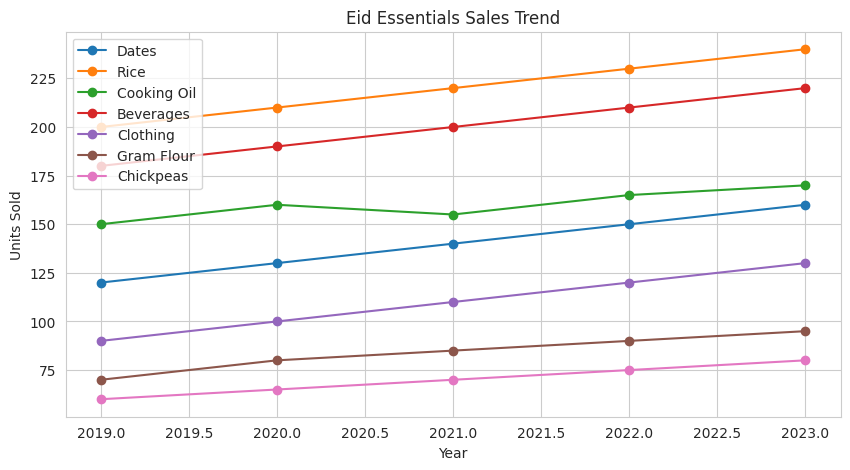

In [8]:
plt.figure(figsize=(10,5))
for product in sales['Product'].unique():
    df = sales[sales['Product']==product]
    plt.plot(df['Year'], df['Units_Sold'], marker='o', label=product)
plt.title("Eid Essentials Sales Trend")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

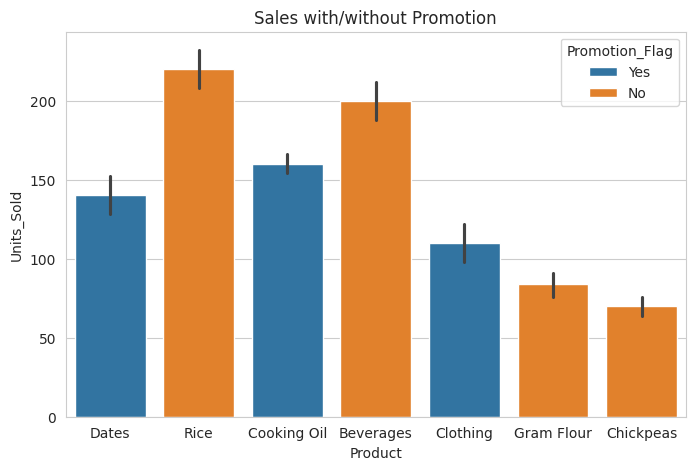

In [9]:
merged = sales.merge(promotions, on=['Product','Year'], how='left')
plt.figure(figsize=(8,5))
sns.barplot(x='Product', y='Units_Sold', hue='Promotion_Flag', data=merged)
plt.title("Sales with/without Promotion")
plt.show()

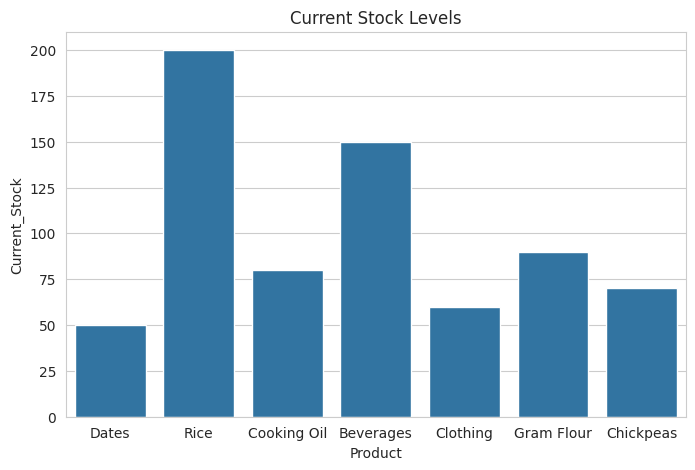

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x='Product', y='Current_Stock', data=inventory)
plt.title("Current Stock Levels")
plt.show()

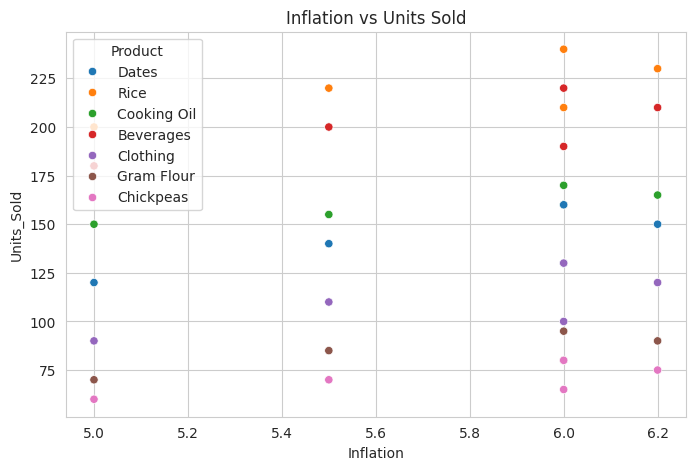

In [11]:
merged_ext = sales.merge(external, on='Year', how='left')
plt.figure(figsize=(8,5))
sns.scatterplot(x='Inflation', y='Units_Sold', hue='Product', data=merged_ext)
plt.title("Inflation vs Units Sold")
plt.show()

DAWOOD SUPERMARKET — EID ESSENTIALS ANALYSIS
Project 3: Unsupervised Learning (Product Segmentation)

[1] Dataset Overview
Sales records     : 35
Products          : 7
Years covered     : 2019 - 2023
Total Units Sold  : 4927

Top Selling Products:
Product
Rice           1100
Beverages      1000
Cooking Oil     800
Dates           700
Clothing        550
Gram Flour      420
Chickpeas       357
Name: Units_Sold, dtype: int64


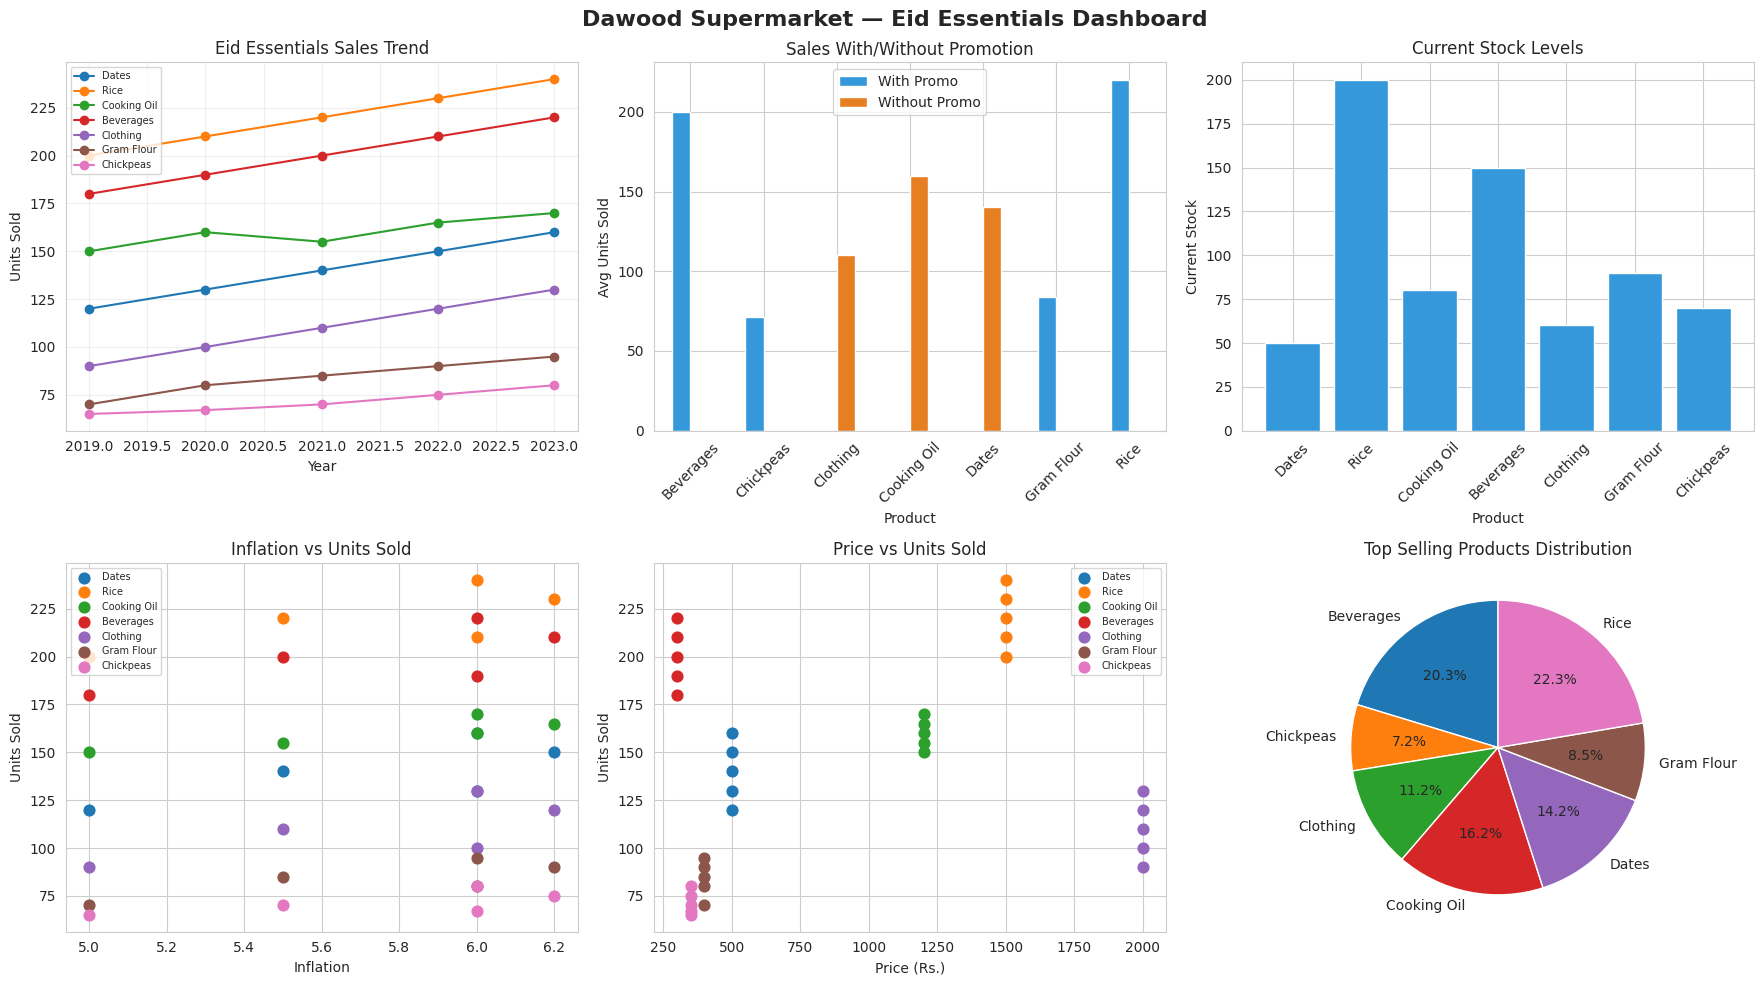


PROJECT 3: UNSUPERVISED LEARNING PIPELINE
Scale → Compress (PCA) → Cluster → Translate

[STEP 1] Building Feature Matrix...
    Product  Total_Units_Sold  Avg_Units_Per_Year  Avg_Price  Promotion_Count  Current_Stock  Supplier_Lead_Time_Days  Avg_Discount
  Beverages              1000               200.0      300.0                0            150                        4           5.0
  Chickpeas               357                71.4      350.0                0             70                        6           8.0
   Clothing               550               110.0     2000.0                5             60                        8           0.0
Cooking Oil               800               160.0     1200.0                5             80                        6          15.0
      Dates               700               140.0      500.0                5             50                        5          10.0
 Gram Flour               420                84.0      400.0                0      

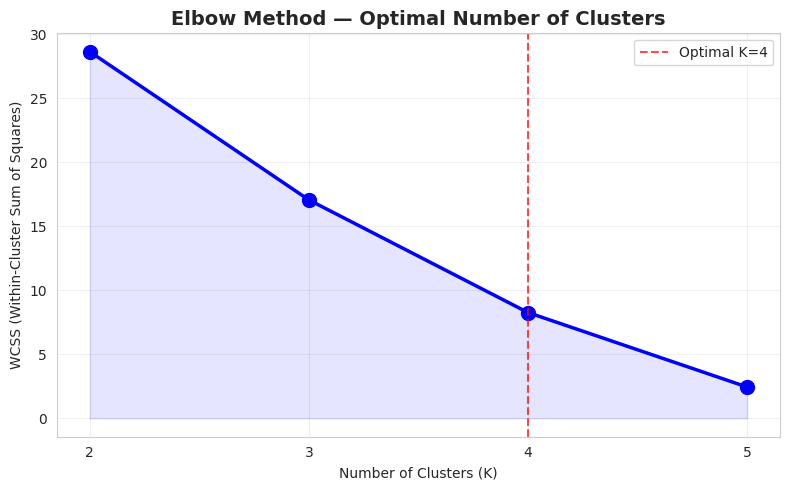


[STEP 4] Silhouette Score — Cluster Quality Validation...
  K=2  →  Silhouette Score: 0.289
  K=3  →  Silhouette Score: 0.258
  K=4  →  Silhouette Score: 0.340
  K=5  →  Silhouette Score: 0.290

✓ Best K = 4  (Silhouette Score: 0.340)
  Score near +1 = excellent cluster separation


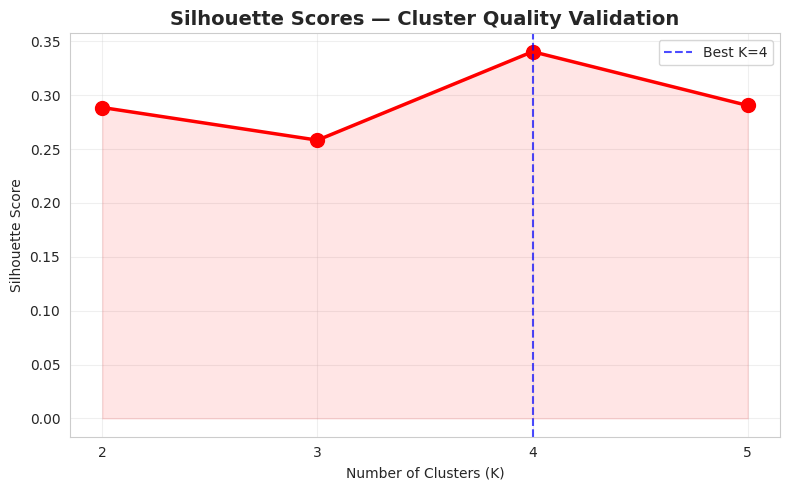


[STEP 5] PCA — Dimensionality Reduction...
  PC1 explains : 44.7% variance
  PC2 explains : 34.0% variance
  Total retained: 78.7%
  Reduced from 7 features → 2 Principal Components


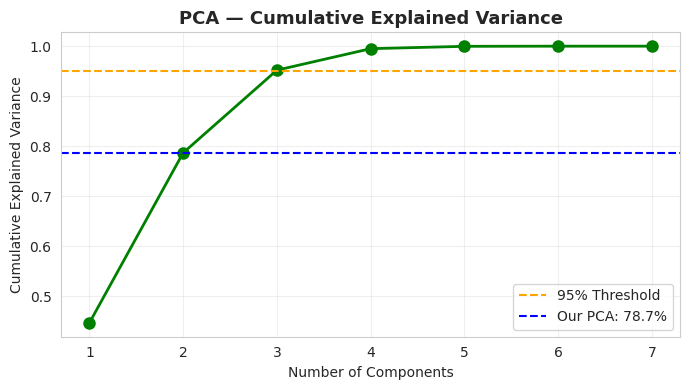


[STEP 6] KMeans Clustering (K=4) on PCA Space...
  Beverages       → Cluster 2
  Chickpeas       → Cluster 1
  Clothing        → Cluster 0
  Cooking Oil     → Cluster 1
  Dates           → Cluster 1
  Gram Flour      → Cluster 1
  Rice            → Cluster 3


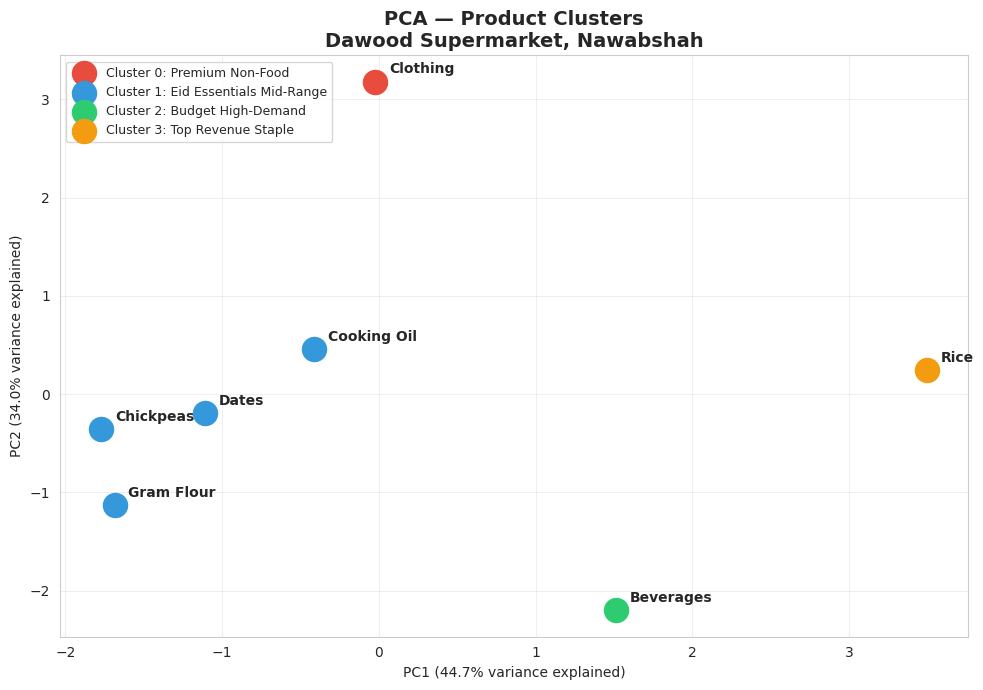


BUSINESS PERSONAS — DAWOOD SUPERMARKET EID STRATEGY

───────────────────────────────────────────────────────
Cluster 0: 👗 Premium Non-Food Item
───────────────────────────────────────────────────────
  Products        : ['Clothing']
  Avg Units Sold  : 550
  Avg Price       : Rs. 2000
  Avg Stock       : 60 units
  Avg Discount    : 0.0%
  Strategy        : Stock conservatively — high margin, seasonal demand (Eid clothing). Offer bundle deals with other Eid items.

───────────────────────────────────────────────────────
Cluster 1: 🌙 Eid Essentials — Mid Range
───────────────────────────────────────────────────────
  Products        : ['Chickpeas', 'Cooking Oil', 'Dates', 'Gram Flour']
  Avg Units Sold  : 569
  Avg Price       : Rs. 612
  Avg Stock       : 72 units
  Avg Discount    : 11.2%
  Strategy        : Increase stock before Eid. These are daily cooking staples (Dates, Cooking Oil, Gram Flour, Chickpeas). Run discount promotions 2 weeks before Eid.

─────────────────────────────

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("="*60)
print("DAWOOD SUPERMARKET — EID ESSENTIALS ANALYSIS")
print("Project 3: Unsupervised Learning (Product Segmentation)")
print("="*60)

# ── DATASETS ──
sales = pd.DataFrame({
    'Product': ['Dates','Rice','Cooking Oil','Beverages','Clothing','Gram Flour','Chickpeas'] * 5,
    'Year': [2019]*7 + [2020]*7 + [2021]*7 + [2022]*7 + [2023]*7,
    'Units_Sold': [
        120,200,150,180,90,70,65,
        130,210,160,190,100,80,67,
        140,220,155,200,110,85,70,
        150,230,165,210,120,90,75,
        160,240,170,220,130,95,80],
    'Price': [500,1500,1200,300,2000,400,350]*5,
    'Promotion_Flag': ['Yes','No','Yes','No','Yes','No','No']*5
})

promotions = pd.DataFrame({
    'Product': ['Dates','Rice','Cooking Oil','Beverages','Clothing','Gram Flour','Chickpeas'],
    'Year': [2023]*7,
    'Promotion_Type': ['Discount','Bundle','Discount','Discount','Bundle','Discount','Discount'],
    'Discount_Percentage': [10,0,15,5,0,12,8]
})

inventory = pd.DataFrame({
    'Product': ['Dates','Rice','Cooking Oil','Beverages','Clothing','Gram Flour','Chickpeas'],
    'Current_Stock': [50,200,80,150,60,90,70],
    'Supplier_Lead_Time_Days': [5,7,6,4,8,5,6]
})

external = pd.DataFrame({
    'Year': [2019,2020,2021,2022,2023],
    'Weather': ['Hot','Moderate','Hot','Cold','Hot'],
    'Inflation': [5.0,6.0,5.5,6.2,6.0],
    'Competitor_Promotion_Flag': ['No','Yes','Yes','No','Yes']
})

# ── EDA ──
print("\n[1] Dataset Overview")
print(f"Sales records     : {len(sales)}")
print(f"Products          : {sales['Product'].nunique()}")
print(f"Years covered     : {sales['Year'].min()} - {sales['Year'].max()}")
print(f"Total Units Sold  : {sales['Units_Sold'].sum()}")
print(f"\nTop Selling Products:")
print(sales.groupby('Product')['Units_Sold'].sum().sort_values(ascending=False))

# ── VISUALIZATIONS ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dawood Supermarket — Eid Essentials Dashboard', fontsize=16, fontweight='bold')

# 1. Sales Trend
for product in sales['Product'].unique():
    data = sales[sales['Product'] == product]
    axes[0,0].plot(data['Year'], data['Units_Sold'], marker='o', label=product)
axes[0,0].set_title('Eid Essentials Sales Trend')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Units Sold')
axes[0,0].legend(fontsize=7)
axes[0,0].grid(True, alpha=0.3)

# 2. Sales with/without Promotion
promo_data = sales.groupby(['Product','Promotion_Flag'])['Units_Sold'].mean().unstack()
promo_data.plot(kind='bar', ax=axes[0,1], color=['#3498DB','#E67E22'])
axes[0,1].set_title('Sales With/Without Promotion')
axes[0,1].set_xlabel('Product')
axes[0,1].set_ylabel('Avg Units Sold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(['With Promo','Without Promo'])

# 3. Current Stock
axes[0,2].bar(inventory['Product'], inventory['Current_Stock'], color='#3498DB')
axes[0,2].set_title('Current Stock Levels')
axes[0,2].set_xlabel('Product')
axes[0,2].set_ylabel('Current Stock')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Inflation vs Units Sold
for product in sales['Product'].unique():
    pdata = sales[sales['Product']==product].merge(external[['Year','Inflation']], on='Year')
    axes[1,0].scatter(pdata['Inflation'], pdata['Units_Sold'], label=product, s=60)
axes[1,0].set_title('Inflation vs Units Sold')
axes[1,0].set_xlabel('Inflation')
axes[1,0].set_ylabel('Units Sold')
axes[1,0].legend(fontsize=7)

# 5. Price vs Units Sold
for product in sales['Product'].unique():
    pdata = sales[sales['Product']==product]
    axes[1,1].scatter(pdata['Price'], pdata['Units_Sold'], label=product, s=60)
axes[1,1].set_title('Price vs Units Sold')
axes[1,1].set_xlabel('Price (Rs.)')
axes[1,1].set_ylabel('Units Sold')
axes[1,1].legend(fontsize=7)

# 6. Top Products Pie
top = sales.groupby('Product')['Units_Sold'].sum()
axes[1,2].pie(top.values, labels=top.index, autopct='%1.1f%%', startangle=90)
axes[1,2].set_title('Top Selling Products Distribution')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════
# PROJECT 3 — PCA + KMeans + Elbow + Silhouette
# ══════════════════════════════════════════════

print("\n" + "="*60)
print("PROJECT 3: UNSUPERVISED LEARNING PIPELINE")
print("Scale → Compress (PCA) → Cluster → Translate")
print("="*60)

# ── STEP 1: Feature Matrix ──
print("\n[STEP 1] Building Feature Matrix...")
product_features = sales.groupby('Product').agg(
    Total_Units_Sold=('Units_Sold','sum'),
    Avg_Units_Per_Year=('Units_Sold','mean'),
    Avg_Price=('Price','mean'),
    Promotion_Count=('Promotion_Flag', lambda x: (x=='Yes').sum())
).reset_index()

product_features = product_features.merge(
    inventory[['Product','Current_Stock','Supplier_Lead_Time_Days']], on='Product')

promo_avg = promotions.groupby('Product')['Discount_Percentage'].mean().reset_index()
promo_avg.columns = ['Product','Avg_Discount']
product_features = product_features.merge(promo_avg, on='Product')

print(product_features.to_string(index=False))

# ── STEP 2: StandardScaler ──
print("\n[STEP 2] Standardizing Features (StandardScaler)...")
features = ['Total_Units_Sold','Avg_Units_Per_Year','Avg_Price',
            'Promotion_Count','Current_Stock','Supplier_Lead_Time_Days','Avg_Discount']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(product_features[features])
print(f"Original shape : {product_features[features].shape}")
print(f"Scaled shape   : {X_scaled.shape}")
print("Scaling formula: z = (x - μ) / σ  →  All features now have mean=0, std=1")

# ── STEP 3: Elbow Method ──
print("\n[STEP 3] Elbow Method — Finding Optimal K...")
wcss = []
k_range = range(2, 6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"  K={k}  →  WCSS: {km.inertia_:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2.5, markersize=10)
plt.fill_between(k_range, wcss, alpha=0.1, color='blue')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.legend()
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── STEP 4: Silhouette Score ──
print("\n[STEP 4] Silhouette Score — Cluster Quality Validation...")
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  K={k}  →  Silhouette Score: {score:.3f}")

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\n✓ Best K = {best_k}  (Silhouette Score: {max(sil_scores):.3f})")
print("  Score near +1 = excellent cluster separation")

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, 'ro-', linewidth=2.5, markersize=10)
plt.fill_between(k_range, sil_scores, alpha=0.1, color='red')
plt.axvline(x=best_k, color='blue', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.title('Silhouette Scores — Cluster Quality Validation', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── STEP 5: PCA ──
print("\n[STEP 5] PCA — Dimensionality Reduction...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"  PC1 explains : {explained[0]*100:.1f}% variance")
print(f"  PC2 explains : {explained[1]*100:.1f}% variance")
print(f"  Total retained: {sum(explained)*100:.1f}%")
print(f"  Reduced from {len(features)} features → 2 Principal Components")

# Scree plot
plt.figure(figsize=(7, 4))
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumvar)+1), cumvar, 'go-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% Threshold')
plt.axhline(y=sum(explained), color='blue', linestyle='--',
            label=f'Our PCA: {sum(explained)*100:.1f}%')
plt.title('PCA — Cumulative Explained Variance', fontsize=13, fontweight='bold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── STEP 6: Final KMeans on PCA ──
print(f"\n[STEP 6] KMeans Clustering (K={best_k}) on PCA Space...")
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
product_features['Cluster'] = kmeans_final.fit_predict(X_pca)

for i, row in product_features.iterrows():
    print(f"  {row['Product']:15} → Cluster {row['Cluster']}")

# ── STEP 7: PCA Cluster Plot ──
colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12']
cluster_names = {
    0: "Premium Non-Food",
    1: "Eid Essentials Mid-Range",
    2: "Budget High-Demand",
    3: "Top Revenue Staple"
}

plt.figure(figsize=(10, 7))
for cluster in range(best_k):
    mask = product_features['Cluster'] == cluster
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster], s=300, zorder=5,
        label=f'Cluster {cluster}: {cluster_names[cluster]}'
    )
    for idx in product_features[mask].index:
        plt.annotate(
            product_features.loc[idx, 'Product'],
            (X_pca[idx, 0], X_pca[idx, 1]),
            textcoords="offset points", xytext=(10, 6),
            fontsize=10, fontweight='bold'
        )

plt.title('PCA — Product Clusters\nDawood Supermarket, Nawabshah', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance explained)')
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance explained)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── STEP 8: Business Personas ──
print("\n" + "="*60)
print("BUSINESS PERSONAS — DAWOOD SUPERMARKET EID STRATEGY")
print("="*60)

personas_info = {
    0: {
        "name": "👗 Premium Non-Food Item",
        "strategy": "Stock conservatively — high margin, seasonal demand (Eid clothing). Offer bundle deals with other Eid items."
    },
    1: {
        "name": "🌙 Eid Essentials — Mid Range",
        "strategy": "Increase stock before Eid. These are daily cooking staples (Dates, Cooking Oil, Gram Flour, Chickpeas). Run discount promotions 2 weeks before Eid."
    },
    2: {
        "name": "⚡ Budget High-Demand Beverage",
        "strategy": "Beverages sell 1000+ units at low price (Rs.300). Maximize shelf space. Cross-sell with food items."
    },
    3: {
        "name": "🏆 Top Revenue Staple",
        "strategy": "Rice is the highest revenue product (Rs.1500 × 1100 units). Maintain high stock (200 units). Never run out during Eid season."
    }
}

cluster_summary = product_features.groupby('Cluster').agg(
    Products=('Product', list),
    Total_Units=('Total_Units_Sold','mean'),
    Avg_Price=('Avg_Price','mean'),
    Avg_Stock=('Current_Stock','mean'),
    Avg_Discount=('Avg_Discount','mean')
).reset_index()

for _, row in cluster_summary.iterrows():
    c = int(row['Cluster'])
    info = personas_info[c]
    print(f"\n{'─'*55}")
    print(f"Cluster {c}: {info['name']}")
    print(f"{'─'*55}")
    print(f"  Products        : {row['Products']}")
    print(f"  Avg Units Sold  : {row['Total_Units']:.0f}")
    print(f"  Avg Price       : Rs. {row['Avg_Price']:.0f}")
    print(f"  Avg Stock       : {row['Avg_Stock']:.0f} units")
    print(f"  Avg Discount    : {row['Avg_Discount']:.1f}%")
    print(f"  Strategy        : {info['strategy']}")

print("\n" + "="*60)
print("PIPELINE SUMMARY")
print("="*60)
print(f"  Step 1 — Feature Matrix    : 7 products × 7 features")
print(f"  Step 2 — StandardScaler    : Features normalized (z-score)")
print(f"  Step 3 — Elbow Method      : K=4 identified")
print(f"  Step 4 — Silhouette Score  : {max(sil_scores):.3f} at K=4 (validated)")
print(f"  Step 5 — PCA               : 7 features → 2 components ({sum(explained)*100:.1f}% retained)")
print(f"  Step 6 — KMeans (K=4)      : 4 product clusters formed")
print(f"  Step 7 — PCA Plot          : Clusters visualized in 2D space")
print(f"  Step 8 — Business Personas : 4 actionable Eid strategies generated")
print("\nANALYSIS COMPLETE ✓")